In [0]:
# ============================================================
# CELL 1: Setup — Load All Gold Tables
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

spark.sql("USE healthcare_db")

# Convert Gold Delta tables → Pandas for plotting
# .toPandas() brings Spark DataFrame into local memory
# Only do this on aggregated/small tables — never on raw millions of rows!

df_hospital  = spark.table("healthcare_db.gold_hospital_summary").toPandas()
df_diagnosis = spark.table("healthcare_db.gold_diagnosis_summary").toPandas()
df_age       = spark.table("healthcare_db.gold_age_summary").toPandas()
df_monthly   = spark.table("healthcare_db.gold_monthly_admissions").toPandas()
df_silver    = spark.table("healthcare_db.silver_patients").toPandas()

print("✅ All Gold tables loaded into Pandas!")
print(f"   Hospitals  : {len(df_hospital)} rows")
print(f"   Diagnoses  : {len(df_diagnosis)} rows")
print(f"   Age Groups : {len(df_age)} rows")
print(f"   Monthly    : {len(df_monthly)} rows")

✅ All Gold tables loaded into Pandas!
   Hospitals  : 5 rows
   Diagnoses  : 8 rows
   Age Groups : 15 rows
   Monthly    : 24 rows


In [0]:
# ============================================================
# CELL 2: Executive KPI Dashboard (Text Summary)
# ============================================================

# These are the TOP-LINE numbers any hospital CEO would want to see.
# We calculate them from our Gold tables.

total_patients    = df_hospital["total_patients"].sum()
total_revenue     = df_hospital["total_revenue"].sum()
avg_cost          = df_diagnosis["avg_cost"].mean()
avg_los           = df_diagnosis["avg_length_of_stay"].mean()
highest_readmit   = df_hospital.loc[df_hospital["readmission_rate_pct"].idxmax()]
costliest_disease = df_diagnosis.loc[df_diagnosis["avg_cost"].idxmax()]

print("=" * 55)
print("       🏥 HEALTHCARE ANALYTICS — EXECUTIVE KPIs")
print("=" * 55)
print(f"  📋 Total Patients Treated     : {total_patients:,}")
print(f"  💰 Total Hospital Revenue     : ${total_revenue:,.2f}")
print(f"  💊 Avg Treatment Cost         : ${avg_cost:,.2f}")
print(f"  🛏️  Avg Length of Stay         : {avg_los:.1f} days")
print(f"  ⚠️  Highest Readmission Rate   : {highest_readmit['hospital']}")
print(f"                                  ({highest_readmit['readmission_rate_pct']}%)")
print(f"  🔬 Most Expensive Diagnosis   : {costliest_disease['diagnosis']}")
print(f"                                  (${costliest_disease['avg_cost']:,.2f} avg)")
print("=" * 55)

       🏥 HEALTHCARE ANALYTICS — EXECUTIVE KPIs
  📋 Total Patients Treated     : 1,000
  💰 Total Hospital Revenue     : $25,100,903.94
  💊 Avg Treatment Cost         : $25,130.63
  🛏️  Avg Length of Stay         : 16.0 days
  ⚠️  Highest Readmission Rate   : Lakeside Clinic
                                  (52.04%)
  🔬 Most Expensive Diagnosis   : HEART FAILURE
                                  ($26,190.38 avg)


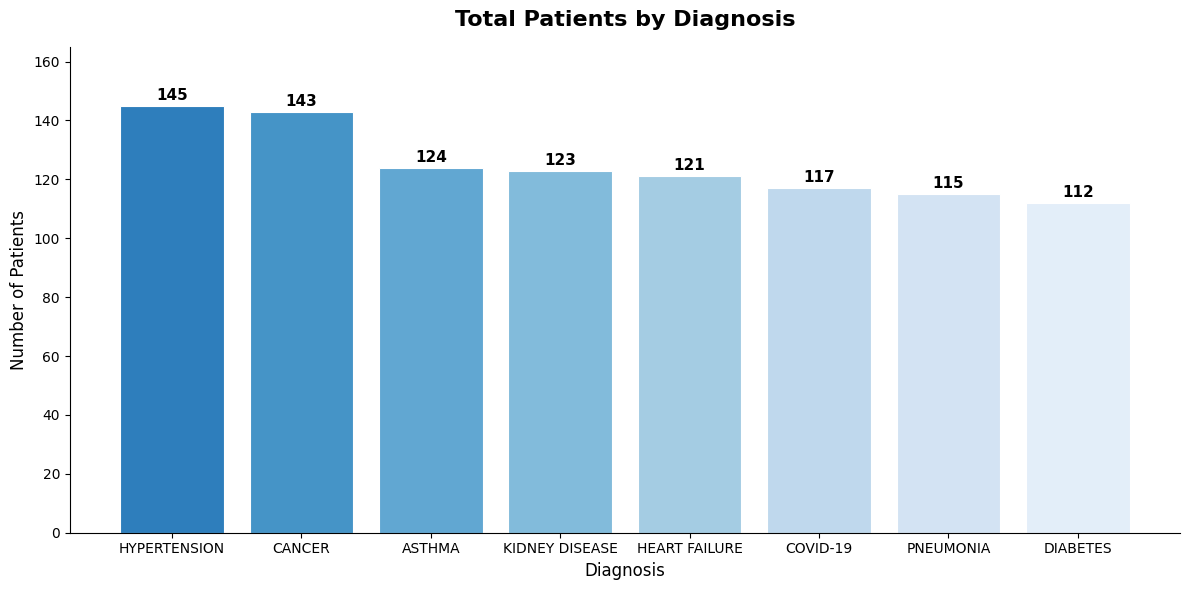

✅ Chart 1 Complete


In [0]:
# ============================================================
# CELL 3: Chart 1 — Total Patients by Diagnosis (Bar Chart)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Sort by total patients descending
df_diag_sorted = df_diagnosis.sort_values("total_patients", ascending=False)

bars = ax.bar(
    df_diag_sorted["diagnosis"],
    df_diag_sorted["total_patients"],
    color=plt.cm.Blues_r(np.linspace(0.3, 0.9, len(df_diag_sorted))),
    edgecolor="white",
    linewidth=0.8
)

# Add value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Total Patients by Diagnosis", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Diagnosis", fontsize=12)
ax.set_ylabel("Number of Patients", fontsize=12)
ax.set_ylim(0, df_diag_sorted["total_patients"].max() + 20)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("✅ Chart 1 Complete")

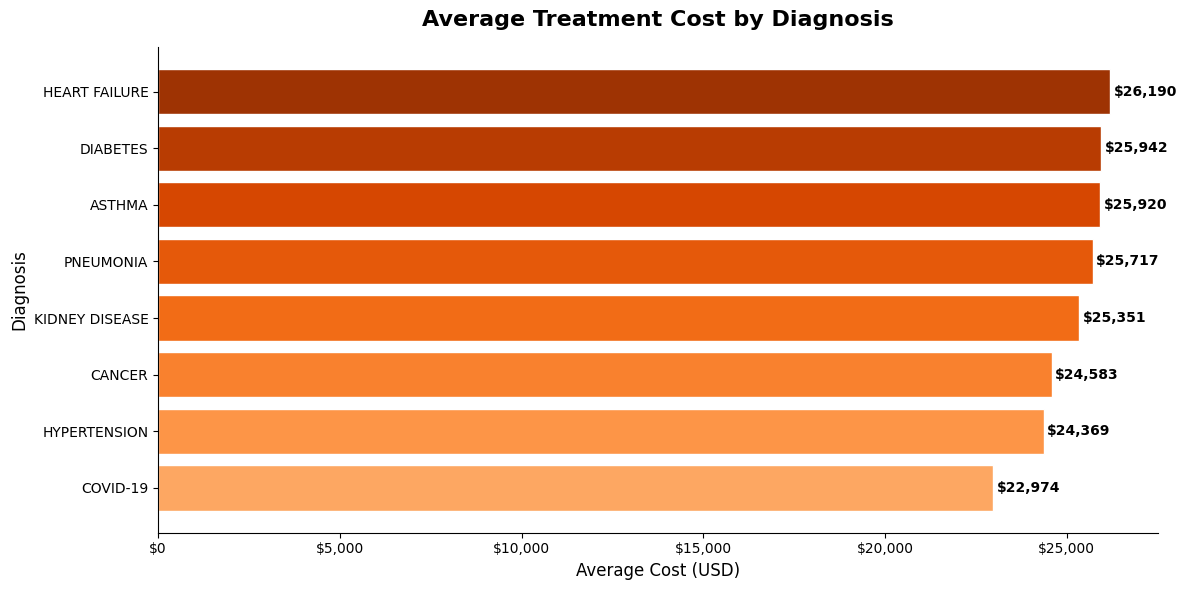

✅ Chart 2 Complete


In [0]:
# ============================================================
# CELL 4: Chart 2 — Average Treatment Cost by Diagnosis
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

df_cost_sorted = df_diagnosis.sort_values("avg_cost", ascending=True)

bars = ax.barh(
    df_cost_sorted["diagnosis"],
    df_cost_sorted["avg_cost"],
    color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(df_cost_sorted))),
    edgecolor="white"
)

# Add dollar labels at the end of each bar
for bar in bars:
    ax.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center", fontsize=10, fontweight="bold"
    )

ax.set_title("Average Treatment Cost by Diagnosis", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Average Cost (USD)", fontsize=12)
ax.set_ylabel("Diagnosis", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("✅ Chart 2 Complete")

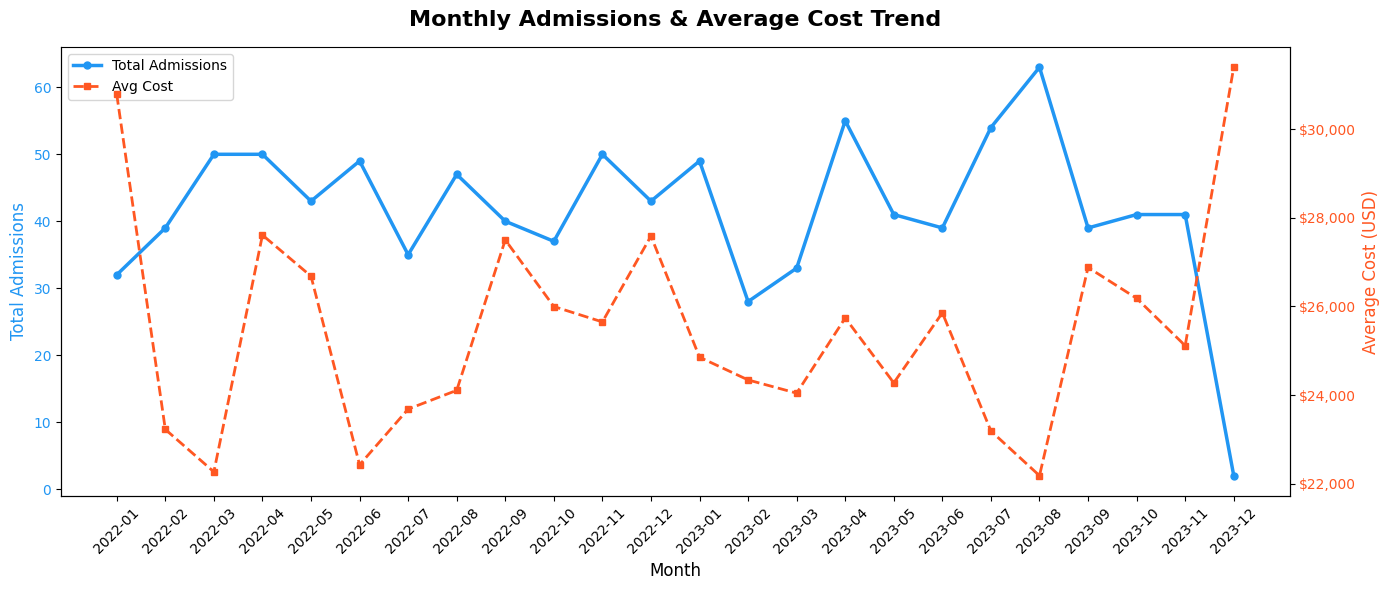

✅ Chart 3 Complete


In [0]:
# ============================================================
# CELL 5: Chart 3 — Monthly Admissions Trend (Line Chart)
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

# Sort by year and month
df_monthly_sorted = df_monthly.sort_values(["year", "month"])

# Line 1 — Total Admissions (left axis)
color1 = "#2196F3"
ax1.plot(
    df_monthly_sorted["year_month"],
    df_monthly_sorted["total_admissions"],
    color=color1, marker="o", linewidth=2.5,
    markersize=5, label="Total Admissions"
)
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Total Admissions", fontsize=12, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.tick_params(axis="x", rotation=45)

# Line 2 — Avg Cost (right axis — dual axis chart!)
ax2 = ax1.twinx()
color2 = "#FF5722"
ax2.plot(
    df_monthly_sorted["year_month"],
    df_monthly_sorted["avg_cost"],
    color=color2, marker="s", linewidth=2,
    markersize=5, linestyle="--", label="Avg Cost"
)
ax2.set_ylabel("Average Cost (USD)", fontsize=12, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax1.set_title("Monthly Admissions & Average Cost Trend", fontsize=16, fontweight="bold", pad=15)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.spines[["top"]].set_visible(False)
plt.tight_layout()
plt.show()

print("✅ Chart 3 Complete")

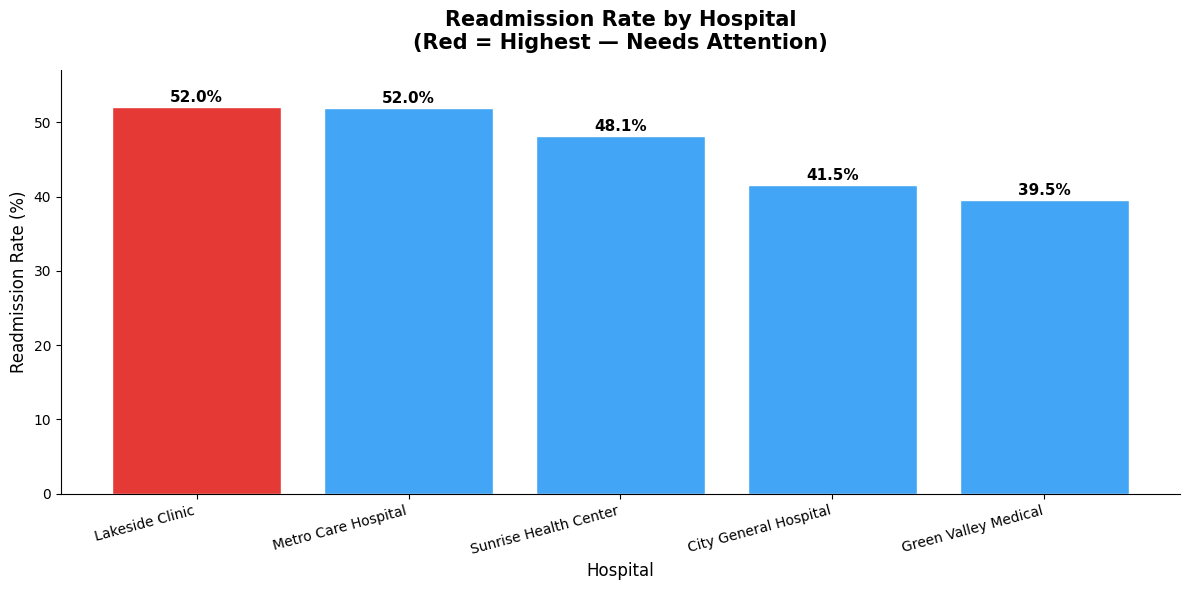

✅ Chart 4 Complete


In [0]:
# ============================================================
# CELL 6: Chart 4 — Readmission Rate by Hospital (Bar Chart)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

df_hosp_sorted = df_hospital.sort_values("readmission_rate_pct", ascending=False)

colors = ["#e53935" if x == df_hosp_sorted["readmission_rate_pct"].max() 
          else "#42a5f5" for x in df_hosp_sorted["readmission_rate_pct"]]

bars = ax.bar(
    df_hosp_sorted["hospital"],
    df_hosp_sorted["readmission_rate_pct"],
    color=colors,
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.1f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Readmission Rate by Hospital\n(Red = Highest — Needs Attention)",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Hospital", fontsize=12)
ax.set_ylabel("Readmission Rate (%)", fontsize=12)
ax.set_ylim(0, df_hosp_sorted["readmission_rate_pct"].max() + 5)
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("✅ Chart 4 Complete")

/home/spark-fd46bf2d-3581-4aa8-9d17-f2/.ipykernel/2716/command-5343294655462376-3113509142:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


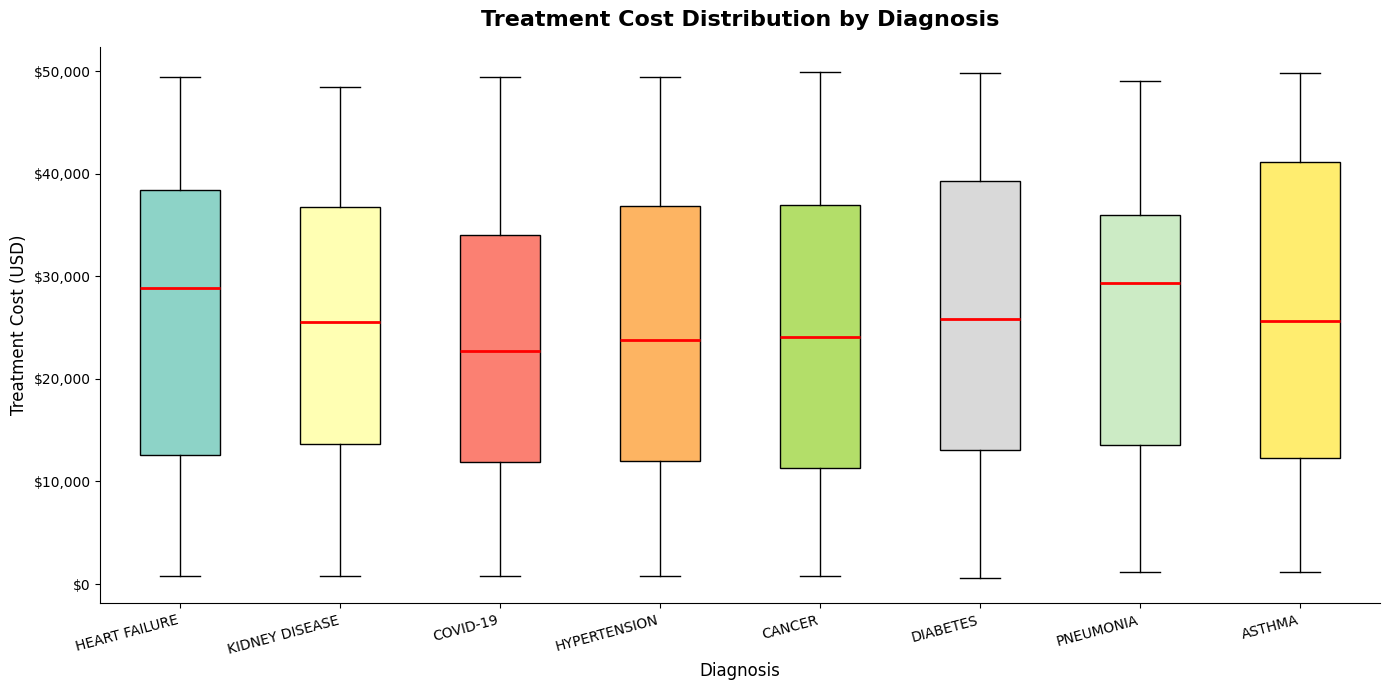

✅ Chart 5 Complete


In [0]:
# ============================================================
# CELL 7: Chart 5 — Treatment Cost Distribution (Box Plot)
# ============================================================

# A box plot shows the SPREAD of data — median, quartiles, outliers.
# This reveals whether costs are consistent or wildly variable
# across diagnoses — critical for insurance pricing.

fig, ax = plt.subplots(figsize=(14, 7))

diagnoses_list = df_silver["diagnosis"].unique()

data_by_diagnosis = [
    df_silver[df_silver["diagnosis"] == d]["treatment_cost"].values
    for d in diagnoses_list
]

bp = ax.boxplot(
    data_by_diagnosis,
    labels=diagnoses_list,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="red", linewidth=2)
)

colors = plt.cm.Set3(np.linspace(0, 1, len(diagnoses_list)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_title("Treatment Cost Distribution by Diagnosis",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Diagnosis", fontsize=12)
ax.set_ylabel("Treatment Cost (USD)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print("✅ Chart 5 Complete")

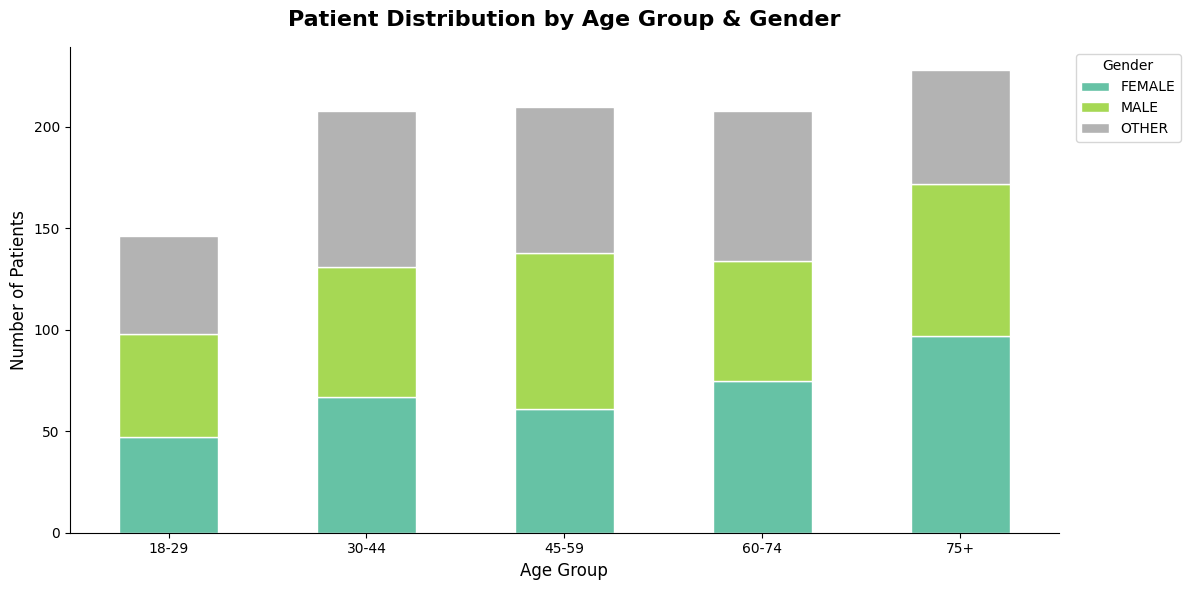

✅ Chart 6 Complete


In [0]:
# ============================================================
# CELL 8: Age Group Patient Distribution (Stacked Bar)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

df_age_pivot = df_age.pivot(
    index="age_group",
    columns="gender",
    values="total_patients"
).fillna(0)

df_age_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="Set2",
    edgecolor="white"
)

ax.set_title("Patient Distribution by Age Group & Gender",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Number of Patients", fontsize=12)
ax.legend(title="Gender", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Chart 6 Complete")